<a href="https://colab.research.google.com/github/nmansour67/skills-introduction-to-github/blob/main/k_Means_ICU_Sepsis_Dentofacial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# K-MEANS CLUSTERING
# ICU Sepsis Patient Segmentation & Risk Profiling
# Based on: Yilmaz Baser et al., Biomedicines 2025, 13, 1449
# Standalone Google Colab Script
# ============================================================
# NOTE: K-Means is an UNSUPERVISED algorithm — it finds hidden
# patient groups WITHOUT being told who survived or died.
# We reveal the mortality rate per cluster AFTER clustering
# to validate whether AI discovered clinically meaningful groups.
# ============================================================
# HOW TO USE:
# 1. Go to colab.research.google.com → New Notebook
# 2. Paste each SECTION into a separate cell
# 3. Run top to bottom with Shift+Enter
# 4. Upload ICU_Sepsis_Dataset.xlsx when prompted
# ============================================================




In [2]:
# ─────────────────────────────────────────────────────────────
# SECTION 1 — Install Libraries
# ─────────────────────────────────────────────────────────────

!pip install scikit-learn pandas numpy matplotlib seaborn openpyxl scipy -q

print("✅ All libraries installed successfully!")




✅ All libraries installed successfully!


In [3]:
# ─────────────────────────────────────────────────────────────
# SECTION 2 — Import Libraries
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score)
from scipy import stats
from scipy.stats import chi2_contingency
import textwrap

print("✅ Libraries imported!")




✅ Libraries imported!


In [4]:
# ─────────────────────────────────────────────────────────────
# SECTION 3 — Upload Dataset
# ─────────────────────────────────────────────────────────────

from google.colab import files

print("📂 Please upload ICU_Sepsis_Dataset.xlsx when prompted...")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print(f"✅ File uploaded: {filename}")




📂 Please upload ICU_Sepsis_Dataset.xlsx when prompted...


Saving ICU Sepsis Dataset.xlsx to ICU Sepsis Dataset.xlsx
✅ File uploaded: ICU Sepsis Dataset.xlsx


In [5]:
# ─────────────────────────────────────────────────────────────
# SECTION 4 — Load and Inspect Data
# ─────────────────────────────────────────────────────────────

df = pd.read_excel(filename, sheet_name='Rawdata', header=0, skiprows=[1])
df = df.drop(columns=[df.columns[0]], errors='ignore')

print(f"📊 Dataset loaded: {df.shape[0]} patients × {df.shape[1]} features")
print(f"\n📋 Column names:\n{list(df.columns)}")
print(f"\n🔍 First 3 rows:")
display(df.head(3))




📊 Dataset loaded: 4520 patients × 45 features

📋 Column names:
['Patient_Accommodation', 'Age', 'Gender', 'Comorbidity', 'Ek_Hastalık_isimlerş', 'Solid_organ_cancer', 'Hematological_Diseases', 'Hypertension', 'Heart_Diseases', 'Diabetes_mellitus', 'Chronic_Renal_Failure', 'Neurological_Diseases', 'KOAH_Asthım', 'Others', 'Length_of_stay_in_intensive_care', 'Mortalite', 'Pulse_rate', 'Respiratory_Rate', 'Systolic_blood_pressure', 'Diastolic_blood_pressure', 'Fever', 'Oxygen_saturation', 'Albumin', 'CRP', 'Glukoz', 'Eosinophil_count', 'HCT', 'Hemoglobin', 'Lymphocyte_count', 'Monocyte_count', 'Neutrophil_count', 'PLT', 'RBC', 'WBC', 'Creatinine', 'NT_PRO_BNP_Pro_Brain_Natriuretic_Peptide', 'Systemic_Inflammatory_Response_Syndrome_SIRS_presence', 'The_National_Early_Warning_Score_NEWS', 'qSOFA_Score', 'History_of_hospitalization_in_the_last_3_months', 'Reproduction_in_Blood_Culture', 'If_Reproduction_is_present_in_Blood_Culture_Factor', 'Direnç_Durumu', 'Culture_Type', 'Antibioterapy']

🔍

,Patient_Accommodation,Age,Gender,Comorbidity,Ek_Hastalık_isimlerş,Solid_organ_cancer,Hematological_Diseases,Hypertension,Heart_Diseases,Diabetes_mellitus,...,NT_PRO_BNP_Pro_Brain_Natriuretic_Peptide,Systemic_Inflammatory_Response_Syndrome_SIRS_presence,The_National_Early_Warning_Score_NEWS,qSOFA_Score,History_of_hospitalization_in_the_last_3_months,Reproduction_in_Blood_Culture,If_Reproduction_is_present_in_Blood_Culture_Factor,Direnç_Durumu,Culture_Type,Antibioterapy
0,1.0,67.0,1.0,1.0,AML,1.0,0.0,0.0,0.0,0.0,...,2525.00,0.0,1.0,0.0,1.0,1.0,Koagulaz Negatif Stafilokok,metisilin dirençli,AEROB KAN KÜLTÜRÜ,Clindamycin
1,1.0,35.0,1.0,1.0,ÖZEFAGUS CA,1.0,0.0,0.0,0.0,0.0,...,301.10,0.0,10.0,2.0,1.0,1.0,Enterococcus faecium,0,AEROB KAN KÜLTÜRÜ,Gentamicin High Level(synergy)
2,1.0,86.0,1.0,1.0,Diyastolik Kalp Yetmezliği +PUMONER HİPERTANSİ...,0.0,0.0,1.0,1.0,0.0,...,0.54,0.0,7.0,2.0,1.0,1.0,Koagulaz Negatif Stafilokok,metisilin dirençli,AEROB KAN KÜLTÜRÜ,Daptomycin


In [6]:
# ─────────────────────────────────────────────────────────────
# SECTION 5 — Data Cleaning & Preprocessing
# ─────────────────────────────────────────────────────────────

TARGET = 'Mortalite'

EXCLUDE_COLS = [
    TARGET, 'Variable', 'Ek_Hastalık_isimlerş',
    'If_Reproduction_is_present_in_Blood_Culture_Factor',
    'Direnç_Durumu', 'Culture_Type', 'Antibioterapy'
]

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in EXCLUDE_COLS]

X = df[feature_cols].copy()
y = df[TARGET].copy()

mask = y.notna()
X, y = X[mask], y[mask].astype(int)
X = X.fillna(X.mean())

print(f"✅ Clean dataset : {X.shape[0]} patients | {X.shape[1]} features")
print(f"   Survived: {(y==0).sum()} | Died: {(y==1).sum()} | "
      f"Mortality: {y.mean()*100:.1f}%")




✅ Clean dataset : 2930 patients | 39 features
   Survived: 1487 | Died: 1348 | Mortality: 55.7%


In [7]:
# ─────────────────────────────────────────────────────────────
# SECTION 6 — Feature Engineering (Composite Biomarkers)
# ─────────────────────────────────────────────────────────────

print("\n⚗️  Engineering composite biomarkers...")

if 'CRP' in X.columns and 'Albumin' in X.columns:
    X['FE_CRP_Albumin_Ratio'] = X['CRP'] / (X['Albumin'] + 1e-6)
    print("  ✅ CRP/Albumin Ratio")

if 'Neutrophil_count' in X.columns and 'Lymphocyte_count' in X.columns:
    X['FE_NLR'] = X['Neutrophil_count'] / (X['Lymphocyte_count'] + 1e-6)
    print("  ✅ NLR (Neutrophil/Lymphocyte Ratio)")

if 'PLT' in X.columns and 'Lymphocyte_count' in X.columns:
    X['FE_PLR'] = X['PLT'] / (X['Lymphocyte_count'] + 1e-6)
    print("  ✅ PLR (Platelet/Lymphocyte Ratio)")

if 'Pulse_rate' in X.columns and 'Systolic_blood_pressure' in X.columns:
    X['FE_Shock_Index'] = X['Pulse_rate'] / (X['Systolic_blood_pressure'] + 1e-6)
    print("  ✅ Shock Index (HR/SBP)")

if 'Oxygen_saturation' in X.columns:
    X['FE_O2_Deficit'] = 100 - X['Oxygen_saturation']
    print("  ✅ O2 Deficit")

if 'Creatinine' in X.columns and 'Albumin' in X.columns:
    X['FE_Creatinine_Albumin'] = X['Creatinine'] / (X['Albumin'] + 1e-6)
    print("  ✅ Creatinine/Albumin Ratio")

if 'WBC' in X.columns:
    X['FE_WBC_Aberration'] = abs(X['WBC'] - 7.5)
    print("  ✅ WBC Aberration")

eng_features = [c for c in X.columns if c.startswith('FE_')]
print(f"\n✅ Final feature set: {X.shape[1]} features "
      f"({len(eng_features)} engineered)")





⚗️  Engineering composite biomarkers...
  ✅ CRP/Albumin Ratio
  ✅ NLR (Neutrophil/Lymphocyte Ratio)
  ✅ PLR (Platelet/Lymphocyte Ratio)
  ✅ Shock Index (HR/SBP)
  ✅ O2 Deficit
  ✅ Creatinine/Albumin Ratio
  ✅ WBC Aberration

✅ Final feature set: 46 features (7 engineered)


In [8]:
# ─────────────────────────────────────────────────────────────
# SECTION 7 — Scale Features
# K-Means is distance-based — scaling is mandatory
# ─────────────────────────────────────────────────────────────

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("✅ Features scaled with StandardScaler (required for K-Means)")




✅ Features scaled with StandardScaler (required for K-Means)


In [9]:
# ─────────────────────────────────────────────────────────────
# SECTION 8 — Find Optimal Number of Clusters (k)
# Two methods: Elbow Method + Silhouette Score
# ─────────────────────────────────────────────────────────────

print("\n🔍 Finding optimal number of clusters (k = 2 to 8)...")

k_range      = range(2, 9)
inertia      = []
silhouette   = []
davies       = []
calinski     = []

for k in k_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    lbl = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, lbl))
    davies.append(davies_bouldin_score(X_scaled, lbl))
    calinski.append(calinski_harabasz_score(X_scaled, lbl))
    print(f"  k={k} | Inertia={km.inertia_:.0f} | "
          f"Silhouette={silhouette[-1]:.3f} | "
          f"Davies-Bouldin={davies[-1]:.3f}")

# Best k by silhouette (highest = best separation)
best_k = list(k_range)[np.argmax(silhouette)]
print(f"\n✅ Optimal k = {best_k}  (highest Silhouette score: {max(silhouette):.3f})")





🔍 Finding optimal number of clusters (k = 2 to 8)...
  k=2 | Inertia=117380 | Silhouette=0.146 | Davies-Bouldin=2.531
  k=3 | Inertia=112237 | Silhouette=0.151 | Davies-Bouldin=2.485
  k=4 | Inertia=106599 | Silhouette=0.074 | Davies-Bouldin=2.285
  k=5 | Inertia=101462 | Silhouette=0.091 | Davies-Bouldin=2.345
  k=6 | Inertia=99149 | Silhouette=0.083 | Davies-Bouldin=2.399
  k=7 | Inertia=97041 | Silhouette=0.062 | Davies-Bouldin=2.449
  k=8 | Inertia=93732 | Silhouette=0.078 | Davies-Bouldin=2.408

✅ Optimal k = 3  (highest Silhouette score: 0.151)


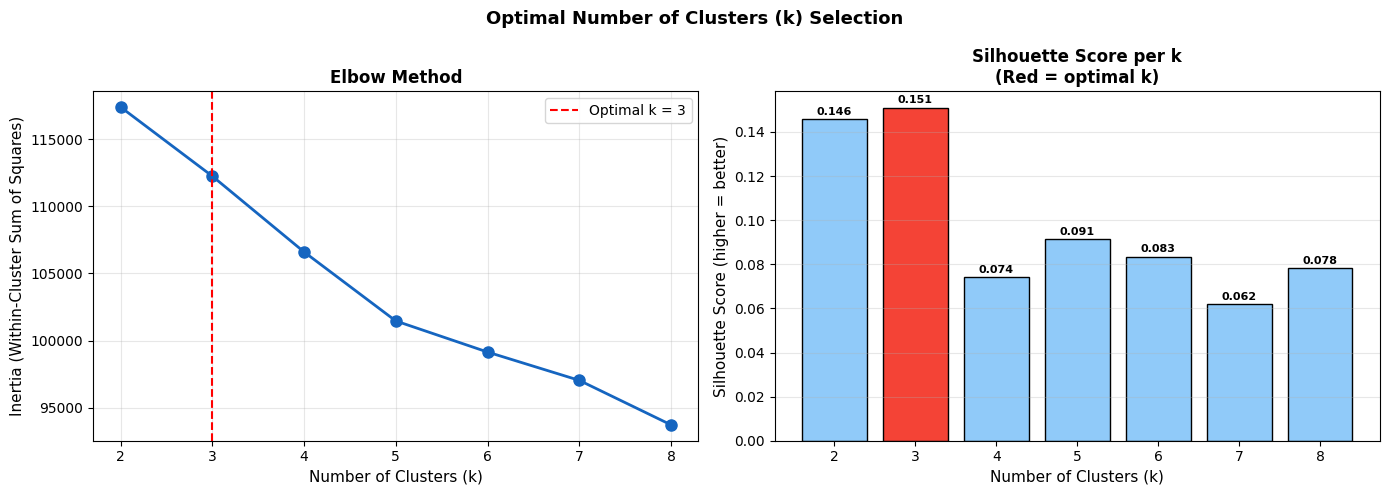

✅ Saved: KMeans_OptimalK.png


In [10]:
# ─────────────────────────────────────────────────────────────
# SECTION 9 — Plot Optimal k Selection
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optimal Number of Clusters (k) Selection',
             fontsize=13, fontweight='bold')

# Elbow plot
axes[0].plot(list(k_range), inertia, 'o-', color='#1565C0', lw=2, ms=8)
axes[0].axvline(best_k, color='red', linestyle='--', lw=1.5,
                label=f'Optimal k = {best_k}')
axes[0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=11)
axes[0].set_title('Elbow Method', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Silhouette plot
bar_colors = ['#F44336' if k == best_k else '#90CAF9' for k in k_range]
axes[1].bar(list(k_range), silhouette, color=bar_colors, edgecolor='black')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1].set_ylabel('Silhouette Score (higher = better)', fontsize=11)
axes[1].set_title('Silhouette Score per k\n(Red = optimal k)',
                  fontsize=12, fontweight='bold')
for i, v in enumerate(silhouette):
    axes[1].text(list(k_range)[i], v + 0.002, f'{v:.3f}',
                 ha='center', fontsize=8, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('KMeans_OptimalK.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: KMeans_OptimalK.png")




In [11]:
# ─────────────────────────────────────────────────────────────
# SECTION 10 — Run Final K-Means with Optimal k
# ─────────────────────────────────────────────────────────────

print(f"\n🚀 Running K-Means with k = {best_k}...")

kmeans        = KMeans(n_clusters=best_k, random_state=42, n_init=10, max_iter=300)
cluster_labels = kmeans.fit_predict(X_scaled)

# Attach results to a results dataframe
results_df               = X.copy()
results_df['Cluster']    = cluster_labels
results_df['Mortality']  = y.values

print(f"✅ K-Means complete! Cluster distribution:")
for c in range(best_k):
    n         = (cluster_labels == c).sum()
    mort_rate = results_df.loc[results_df['Cluster']==c, 'Mortality'].mean() * 100
    print(f"   Cluster {c}: {n} patients | Mortality rate: {mort_rate:.1f}%")

# Evaluation metrics
sil  = silhouette_score(X_scaled, cluster_labels)
dbi  = davies_bouldin_score(X_scaled, cluster_labels)
chi  = calinski_harabasz_score(X_scaled, cluster_labels)
print(f"\n📊 Cluster Quality Metrics:")
print(f"   Silhouette Score    : {sil:.3f}  (range -1 to 1; higher = better)")
print(f"   Davies-Bouldin Index: {dbi:.3f}  (lower = better)")
print(f"   Calinski-Harabasz   : {chi:.1f}  (higher = better)")





🚀 Running K-Means with k = 3...
✅ K-Means complete! Cluster distribution:
   Cluster 0: 1878 patients | Mortality rate: 42.1%
   Cluster 1: 551 patients | Mortality rate: 99.8%
   Cluster 2: 501 patients | Mortality rate: 58.5%

📊 Cluster Quality Metrics:
   Silhouette Score    : 0.151  (range -1 to 1; higher = better)
   Davies-Bouldin Index: 2.485  (lower = better)
   Calinski-Harabasz   : 255.7  (higher = better)


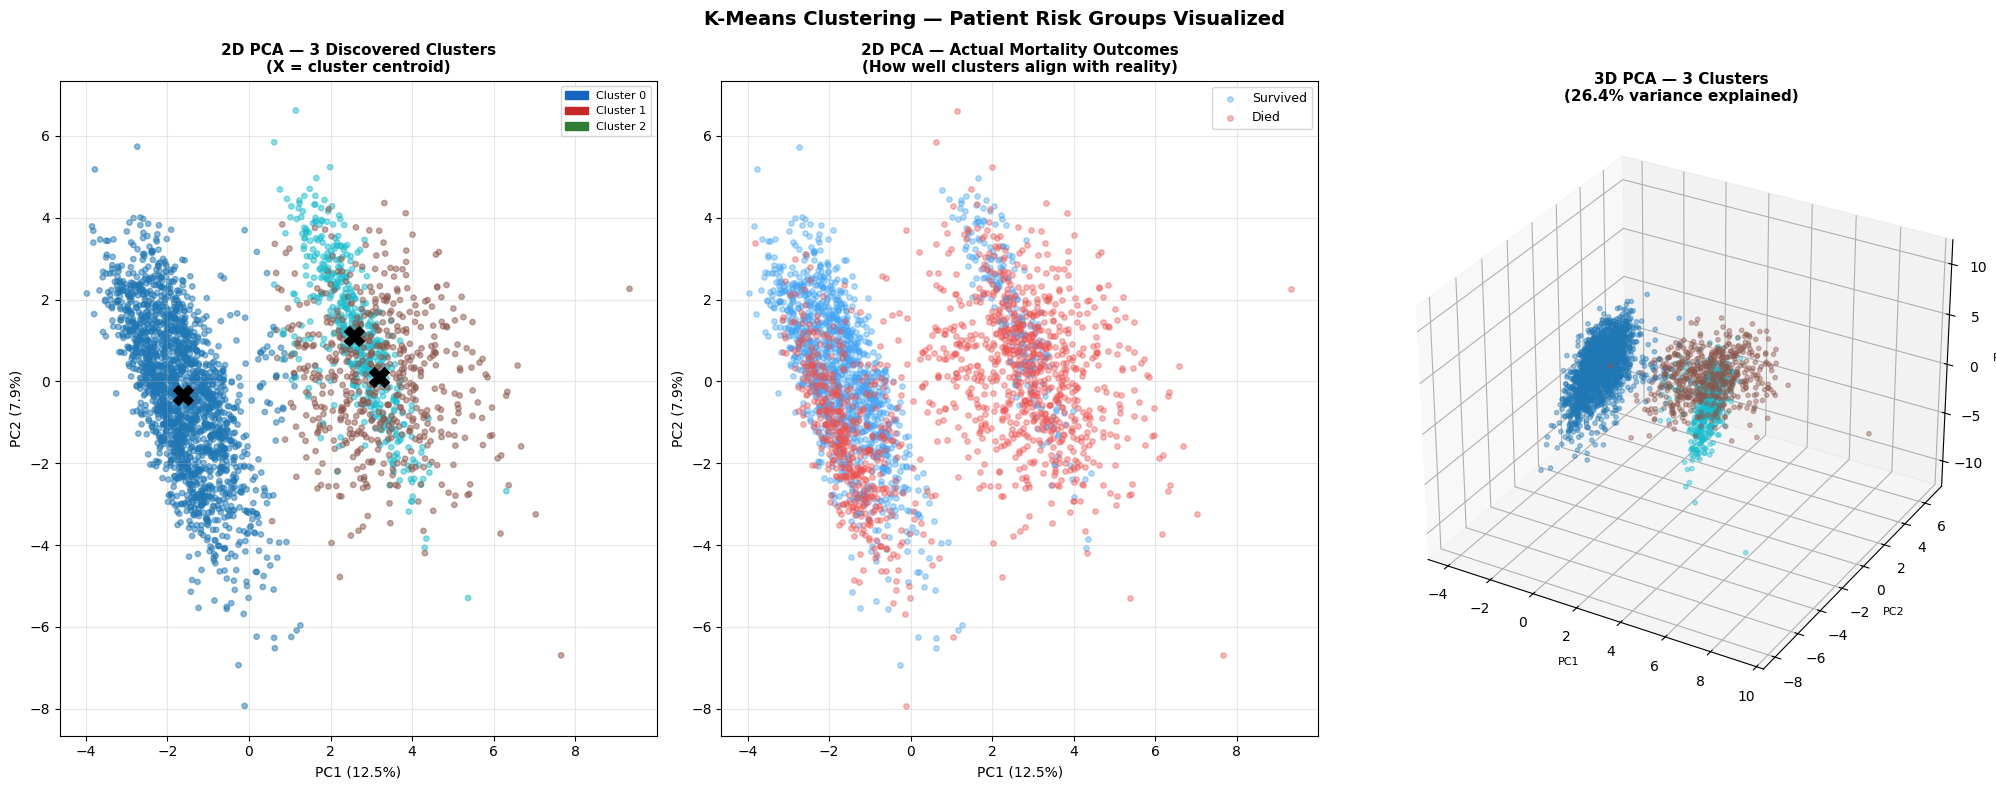

✅ Saved: KMeans_Clusters.png


In [12]:
# ─────────────────────────────────────────────────────────────
# SECTION 11 — Visualize Clusters (PCA 2D + 3D)
# ─────────────────────────────────────────────────────────────

pca2   = PCA(n_components=2, random_state=42)
X_2d   = pca2.fit_transform(X_scaled)

pca3   = PCA(n_components=3, random_state=42)
X_3d   = pca3.fit_transform(X_scaled)

# Color palette for clusters
cluster_palette = ['#1565C0', '#C62828', '#2E7D32', '#F57F17',
                   '#6A1B9A', '#00838F', '#4E342E']
colors_by_cluster  = [cluster_palette[c] for c in cluster_labels]
colors_by_mortality = ['#EF5350' if m == 1 else '#42A5F5' for m in y.values]

fig = plt.figure(figsize=(20, 8))
fig.suptitle('K-Means Clustering — Patient Risk Groups Visualized',
             fontsize=14, fontweight='bold')

# ── Plot 1: 2D PCA — colored by cluster ──────────────────────
ax1 = fig.add_subplot(1, 3, 1)
scatter = ax1.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=cluster_labels, cmap='tab10', alpha=0.5, s=15)
# Plot cluster centroids
centroids_2d = pca2.transform(kmeans.cluster_centers_)
ax1.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            c='black', marker='X', s=200, zorder=10, label='Centroids')
ax1.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
ax1.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
ax1.set_title(f'2D PCA — {best_k} Discovered Clusters\n(X = cluster centroid)',
              fontsize=11, fontweight='bold')
patches = [mpatches.Patch(color=cluster_palette[c], label=f'Cluster {c}')
           for c in range(best_k)]
ax1.legend(handles=patches, fontsize=8, loc='best')
ax1.grid(True, alpha=0.3)

# ── Plot 2: 2D PCA — colored by actual mortality ─────────────
ax2 = fig.add_subplot(1, 3, 2)
ax2.scatter(X_2d[y.values==0, 0], X_2d[y.values==0, 1],
            c='#42A5F5', alpha=0.4, s=15, label='Survived')
ax2.scatter(X_2d[y.values==1, 0], X_2d[y.values==1, 1],
            c='#EF5350', alpha=0.4, s=15, label='Died')
ax2.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
ax2.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
ax2.set_title('2D PCA — Actual Mortality Outcomes\n(How well clusters align with reality)',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# ── Plot 3: 3D PCA — colored by cluster ──────────────────────
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
ax3.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2],
            c=cluster_labels, cmap='tab10', alpha=0.4, s=10)
ax3.set_xlabel('PC1', fontsize=8)
ax3.set_ylabel('PC2', fontsize=8)
ax3.set_zlabel('PC3', fontsize=8)
ax3.set_title(f'3D PCA — {best_k} Clusters\n'
              f'({sum(pca3.explained_variance_ratio_)*100:.1f}% variance explained)',
              fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('KMeans_Clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: KMeans_Clusters.png")




In [13]:
# ─────────────────────────────────────────────────────────────
# SECTION 12 — Cluster Clinical Profiles
# What does each cluster actually represent clinically?
# ─────────────────────────────────────────────────────────────

print("\n" + "="*65)
print("  🏥  CLUSTER CLINICAL PROFILES")
print("="*65)

# Key clinical features to profile
profile_features = [
    c for c in [
        'Age', 'Albumin', 'CRP', 'WBC', 'Neutrophil_count',
        'Lymphocyte_count', 'Systolic_blood_pressure', 'Pulse_rate',
        'Oxygen_saturation', 'Creatinine', 'Fever',
        'The_National_Early_Warning_Score_NEWS', 'qSOFA_Score',
        'FE_CRP_Albumin_Ratio', 'FE_NLR', 'FE_Shock_Index'
    ] if c in results_df.columns
]

profile_df = results_df.groupby('Cluster')[profile_features + ['Mortality']].mean()
profile_df['Mortality %'] = profile_df['Mortality'] * 100
profile_df = profile_df.drop(columns=['Mortality'])

print("\n  Cluster mean values for key clinical features:\n")
print(profile_df.round(2).T.to_string())

# Assign risk labels based on mortality rate
mortality_by_cluster = results_df.groupby('Cluster')['Mortality'].mean() * 100
risk_labels = {}
sorted_clusters = mortality_by_cluster.sort_values()
labels_list = ['🟢 LOW RISK', '🟡 MODERATE RISK', '🔴 HIGH RISK',
               '🔴 VERY HIGH RISK', '⚫ CRITICAL']
for rank, (c, _) in enumerate(sorted_clusters.items()):
    risk_labels[c] = labels_list[min(rank, len(labels_list)-1)]

print(f"\n  📋 AI-Discovered Patient Risk Groups:")
print(f"  {'Cluster':<10} {'Risk Label':<22} {'N Patients':<14} {'Mortality Rate'}")
print(f"  {'-'*60}")
for c in range(best_k):
    n    = (cluster_labels == c).sum()
    mort = mortality_by_cluster[c]
    print(f"  {c:<10} {risk_labels[c]:<22} {n:<14} {mort:.1f}%")





  🏥  CLUSTER CLINICAL PROFILES

  Cluster mean values for key clinical features:

Cluster                                     0       1       2
Age                                     63.74   68.55   65.32
Albumin                                 32.16   28.35   30.62
CRP                                     79.38  101.03   95.98
WBC                                     12.87   16.95   13.86
Neutrophil_count                        10.75   10.54   11.60
Lymphocyte_count                         1.14    1.37    1.08
Systolic_blood_pressure                112.80   83.48   72.15
Pulse_rate                              78.58   55.53   41.21
Oxygen_saturation                       97.61   76.98   95.62
Creatinine                               1.40    1.46    1.51
Fever                                   38.18   35.50   36.49
The_National_Early_Warning_Score_NEWS    1.88    9.23    7.81
qSOFA_Score                              0.12    0.67    1.86
FE_CRP_Albumin_Ratio                     2.79    

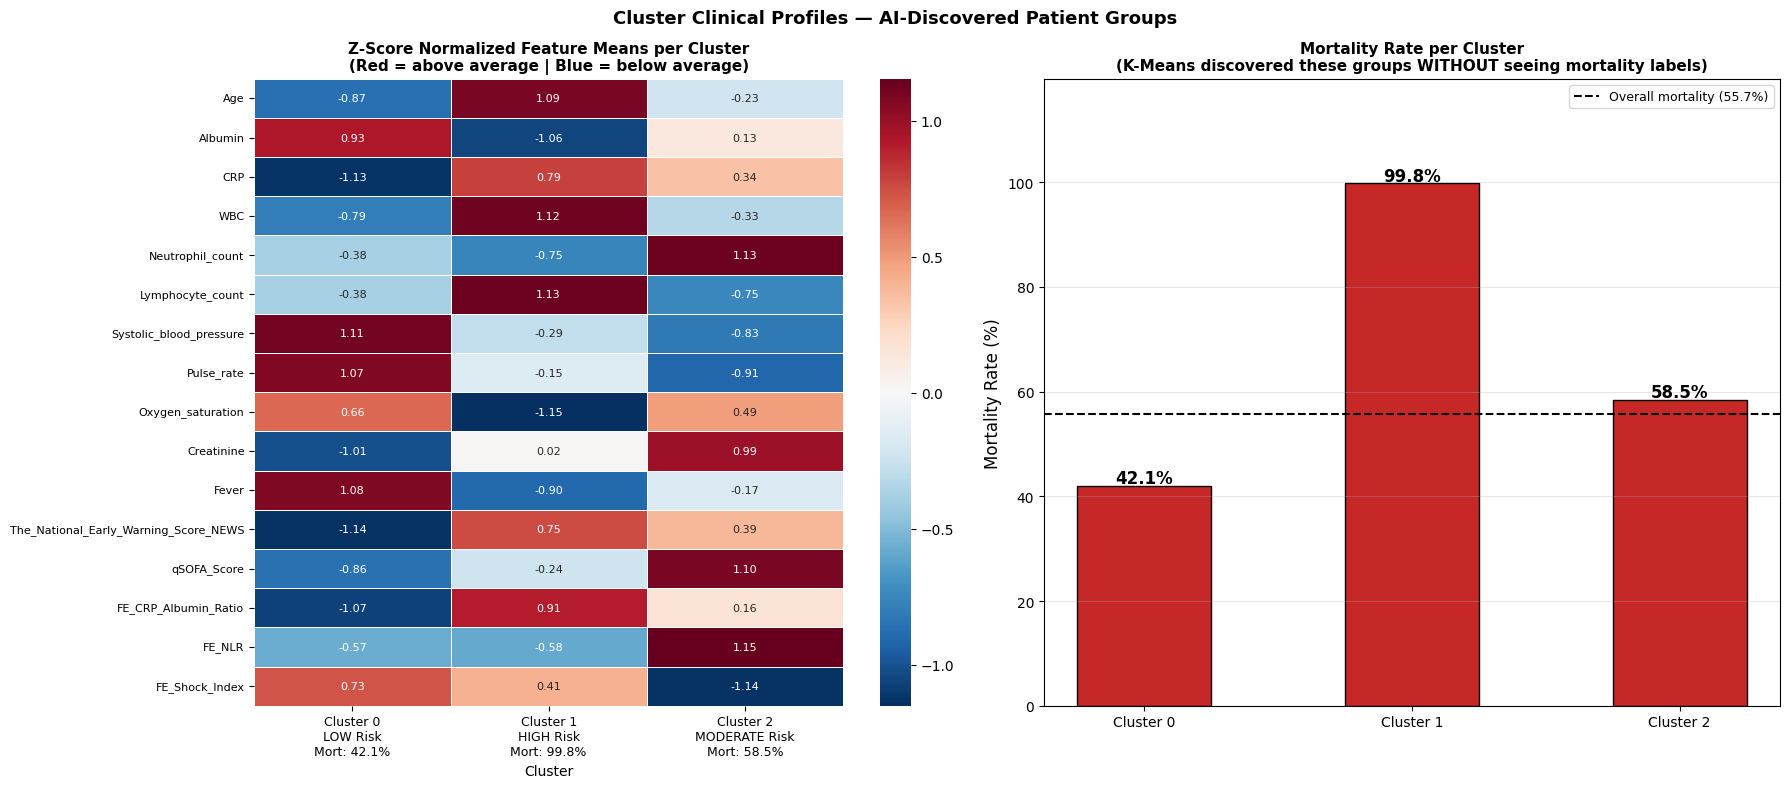

✅ Saved: KMeans_ClusterProfiles.png


In [14]:
# ─────────────────────────────────────────────────────────────
# SECTION 12B — Cluster Heatmap (visual profile)
# ─────────────────────────────────────────────────────────────

# Normalize for heatmap (z-score per feature)
heatmap_data = profile_df.drop(columns=['Mortality %'], errors='ignore').T
heatmap_norm = (heatmap_data - heatmap_data.mean(axis=1).values.reshape(-1,1)) / \
               (heatmap_data.std(axis=1).values.reshape(-1,1) + 1e-6)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Cluster Clinical Profiles — AI-Discovered Patient Groups',
             fontsize=13, fontweight='bold')

# Heatmap
sns.heatmap(heatmap_norm, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=axes[0],
            annot_kws={'size': 8},
            xticklabels=[f'Cluster {c}\n{risk_labels[c].split()[1]} Risk\n'
                         f'Mort: {mortality_by_cluster[c]:.1f}%'
                         for c in range(best_k)])
axes[0].set_title('Z-Score Normalized Feature Means per Cluster\n'
                  '(Red = above average | Blue = below average)',
                  fontsize=11, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0, fontsize=9)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=8)

# Mortality rate bar per cluster
mort_vals   = [mortality_by_cluster[c] for c in range(best_k)]
bar_colors  = ['#C62828' if m > 40 else '#FB8C00' if m > 20 else '#388E3C'
               for m in mort_vals]
axes[1].bar([f'Cluster {c}' for c in range(best_k)],
            mort_vals, color=bar_colors, edgecolor='black', width=0.5)
for i, v in enumerate(mort_vals):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center',
                 fontweight='bold', fontsize=12)
axes[1].axhline(y.mean()*100, color='black', linestyle='--', lw=1.5,
                label=f'Overall mortality ({y.mean()*100:.1f}%)')
axes[1].set_ylabel('Mortality Rate (%)', fontsize=12)
axes[1].set_title('Mortality Rate per Cluster\n'
                  '(K-Means discovered these groups WITHOUT seeing mortality labels)',
                  fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, max(mort_vals) * 1.2)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('KMeans_ClusterProfiles.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: KMeans_ClusterProfiles.png")





  🔬 PATTERN DISCOVERY ENGINE

  Top 10 features that differ significantly across clusters (ANOVA p<0.05):

                 Feature  F-Statistic  p-value Significant
   Patient_Accommodation      628.683      0.0       ✅ YES
                     Age       16.853      0.0       ✅ YES
        Respiratory_Rate     2940.407      0.0       ✅ YES
              Pulse_rate     2168.936      0.0       ✅ YES
       Oxygen_saturation     1811.472      0.0       ✅ YES
                   Fever     1164.159      0.0       ✅ YES
Diastolic_blood_pressure     3875.614      0.0       ✅ YES
                     RBC       35.138      0.0       ✅ YES
                     HCT       30.082      0.0       ✅ YES
              Hemoglobin       34.219      0.0       ✅ YES


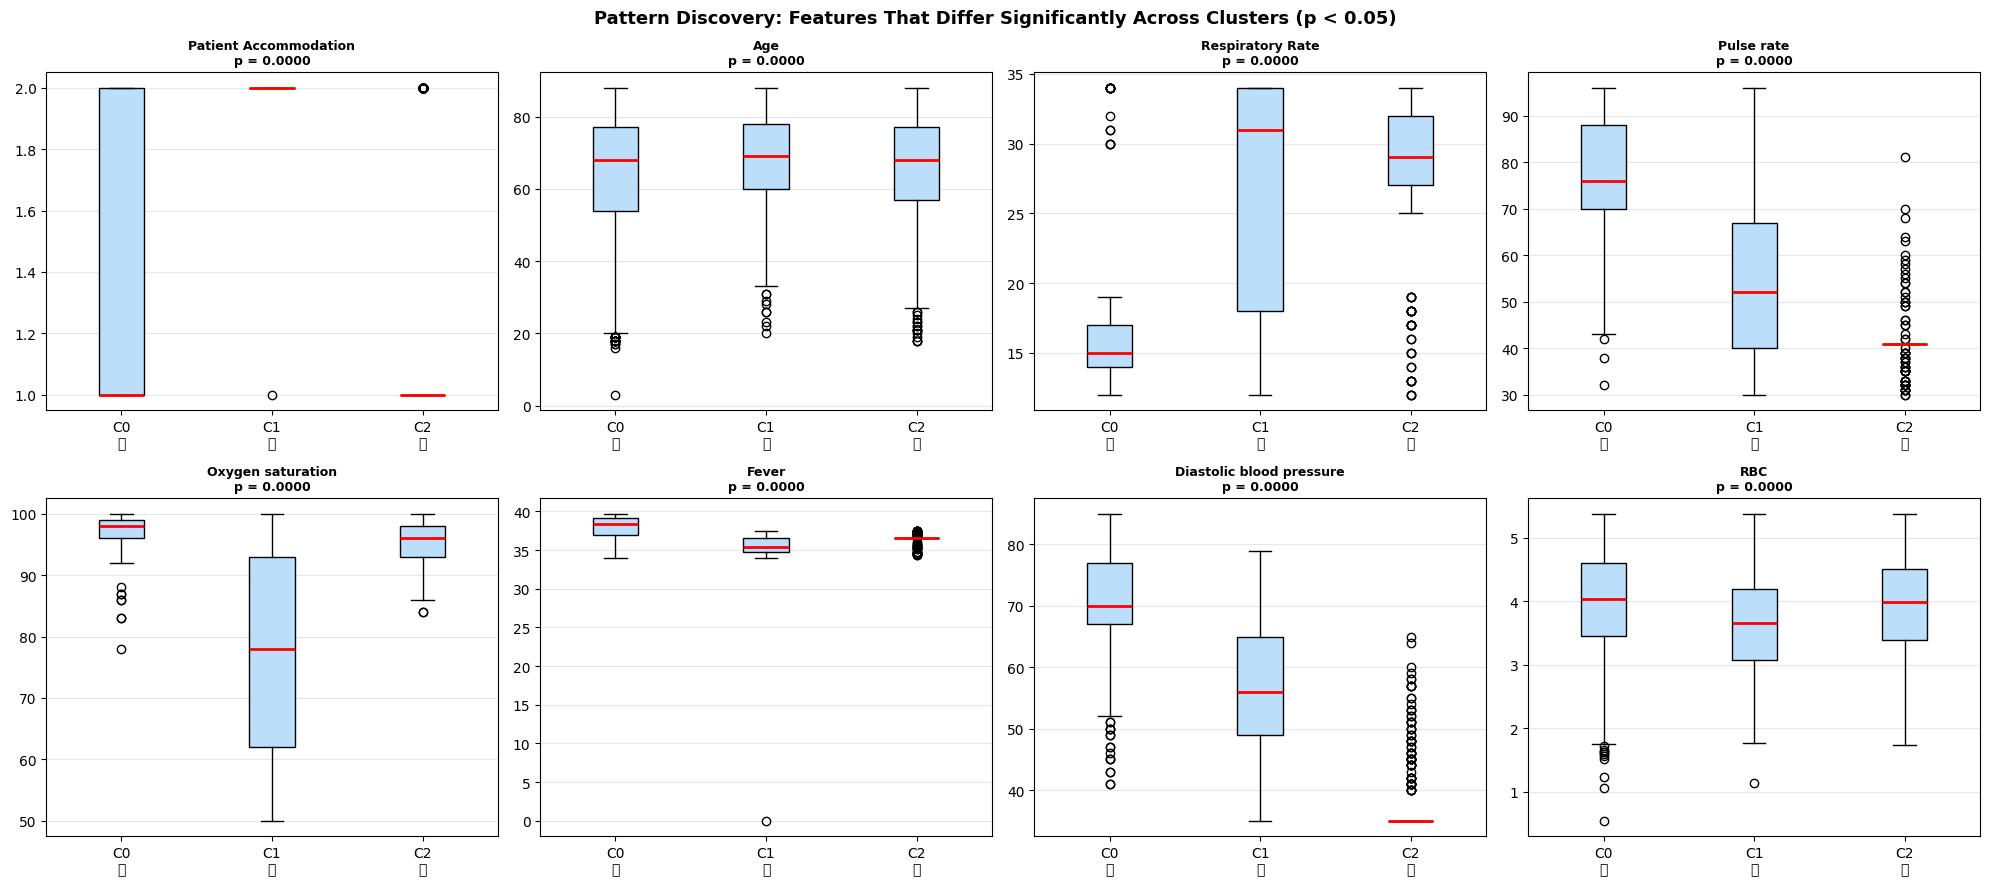

✅ Saved: KMeans_PatternDiscovery.png


In [15]:
# ─────────────────────────────────────────────────────────────
# SECTION 13 — Pattern Discovery Engine
# Statistical significance of features across clusters
# ─────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("  🔬 PATTERN DISCOVERY ENGINE")
print("="*60)

X_analysis          = X.copy()
X_analysis['Cluster']  = cluster_labels
X_analysis['Mortality'] = y.values

# ANOVA across clusters for each feature
pattern_results = []
for col in X.columns:
    groups = [X_analysis.loc[X_analysis['Cluster']==c, col].dropna()
              for c in range(best_k)]
    groups = [g for g in groups if len(g) >= 5]
    if len(groups) < 2:
        continue
    f_stat, p_val = stats.f_oneway(*groups)
    all_vals      = X_analysis[col].dropna()
    pattern_results.append({
        'Feature'     : col,
        'F-Statistic' : round(f_stat, 3),
        'p-value'     : round(p_val, 5),
        'Significant' : '✅ YES' if p_val < 0.05 else '❌ no'
    })

pattern_df   = pd.DataFrame(pattern_results).sort_values('p-value')
top_patterns = pattern_df[pattern_df['p-value'] < 0.05].head(10)
n_sig        = len(top_patterns)

print(f"\n  Top {n_sig} features that differ significantly across clusters (ANOVA p<0.05):\n")
print(top_patterns[['Feature','F-Statistic','p-value','Significant']].to_string(index=False))

# Box plots
top_n = min(8, n_sig)
if top_n > 0:
    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    fig.suptitle('Pattern Discovery: Features That Differ Significantly Across Clusters (p < 0.05)',
                 fontsize=13, fontweight='bold')
    axes = axes.flatten()
    for i, feat in enumerate(top_patterns['Feature'].tolist()[:top_n]):
        ax  = axes[i]
        grp = [X_analysis.loc[X_analysis['Cluster']==c, feat].dropna().clip(
                   upper=X_analysis[feat].quantile(0.95))
               for c in range(best_k)]
        ax.boxplot(grp, labels=[f'C{c}\n{risk_labels[c].split()[0]}'
                                for c in range(best_k)],
                   patch_artist=True,
                   boxprops=dict(facecolor='#BBDEFB'),
                   medianprops=dict(color='red', linewidth=2))
        pv = pattern_df.loc[pattern_df['Feature']==feat, 'p-value'].values[0]
        ax.set_title(f"{feat.replace('FE_','★ ').replace('_',' ')}\np = {pv:.4f}",
                     fontsize=9, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
    for j in range(top_n, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.savefig('KMeans_PatternDiscovery.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: KMeans_PatternDiscovery.png")




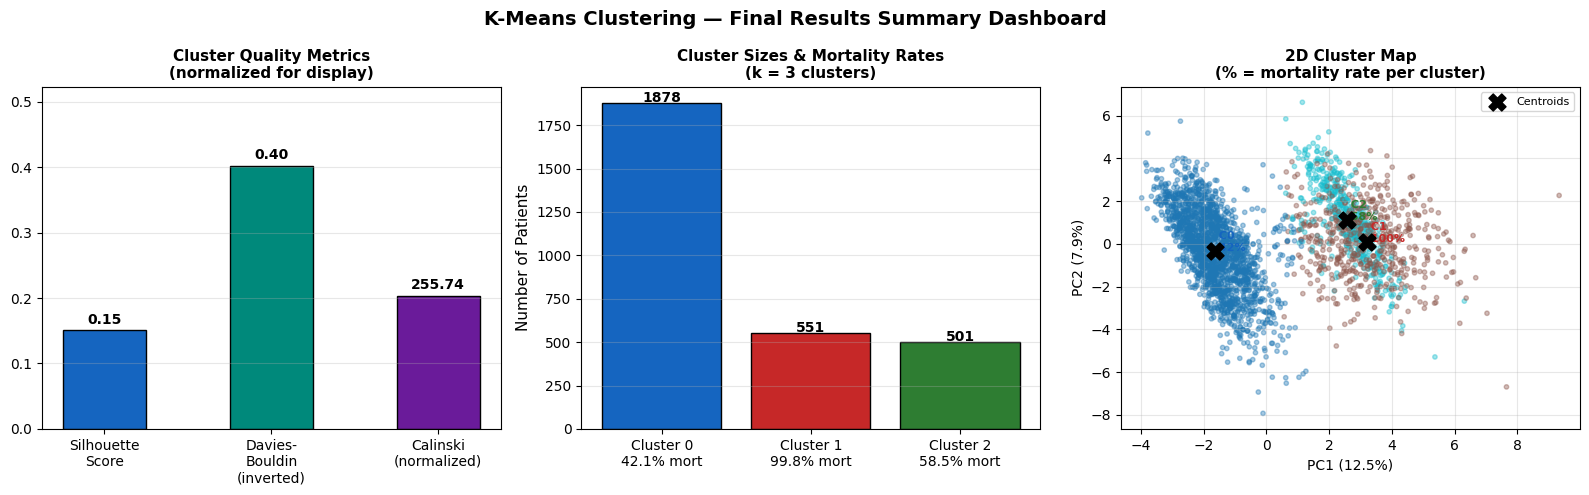

✅ Saved: KMeans_Dashboard.png


In [16]:
# ─────────────────────────────────────────────────────────────
# SECTION 14 — Final Summary Dashboard
# ─────────────────────────────────────────────────────────────

n_total       = len(y)
n_died        = int(y.sum())
n_survived    = n_total - n_died
mortality_pct = y.mean() * 100

fig = plt.figure(figsize=(16, 5))
fig.suptitle('K-Means Clustering — Final Results Summary Dashboard',
             fontsize=14, fontweight='bold')

# Panel 1: Cluster quality metrics
ax1 = fig.add_subplot(1, 3, 1)
q_metrics    = {'Silhouette\nScore': sil,
                'Davies-\nBouldin\n(inverted)': 1 / (dbi + 1e-6),
                'Calinski\n(normalized)': chi / (chi + 1000)}
bar_colors   = ['#1565C0', '#00897B', '#6A1B9A']
bars = ax1.bar(list(q_metrics.keys()), list(q_metrics.values()),
               color=bar_colors, edgecolor='black', width=0.5)
for bar, (name, val) in zip(bars, q_metrics.items()):
    orig_val = sil if 'Sil' in name else (1/(dbi+1e-6) if 'Bouldin' in name else chi)
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{orig_val:.2f}', ha='center', fontweight='bold', fontsize=10)
ax1.set_title('Cluster Quality Metrics\n(normalized for display)',
              fontsize=11, fontweight='bold')
ax1.set_ylim(0, max(q_metrics.values()) * 1.3)
ax1.grid(True, alpha=0.3, axis='y')

# Panel 2: Cluster size + mortality pie-style bar
ax2 = fig.add_subplot(1, 3, 2)
cluster_sizes = [int((cluster_labels == c).sum()) for c in range(best_k)]
bar_colors2   = [cluster_palette[c] for c in range(best_k)]
bars2 = ax2.bar([f'Cluster {c}\n{mortality_by_cluster[c]:.1f}% mort'
                 for c in range(best_k)],
                cluster_sizes, color=bar_colors2, edgecolor='black')
for bar, val in zip(bars2, cluster_sizes):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 5,
             str(val), ha='center', fontweight='bold', fontsize=10)
ax2.set_ylabel('Number of Patients', fontsize=11)
ax2.set_title(f'Cluster Sizes & Mortality Rates\n(k = {best_k} clusters)',
              fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Panel 3: 2D PCA summary scatter (compact)
ax3 = fig.add_subplot(1, 3, 3)
ax3.scatter(X_2d[:, 0], X_2d[:, 1],
            c=cluster_labels, cmap='tab10', alpha=0.4, s=10)
ax3.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            c='black', marker='X', s=150, zorder=10, label='Centroids')
for c in range(best_k):
    ax3.text(centroids_2d[c, 0], centroids_2d[c, 1],
             f' C{c}\n {mortality_by_cluster[c]:.0f}%',
             fontsize=8, fontweight='bold',
             color=cluster_palette[c])
ax3.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
ax3.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
ax3.set_title('2D Cluster Map\n(% = mortality rate per cluster)',
              fontsize=11, fontweight='bold')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('KMeans_Dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: KMeans_Dashboard.png")




In [17]:
# ─────────────────────────────────────────────────────────────
# SECTION 15 — Auto-Generated Narrative Report (≤ 100 words)
# ─────────────────────────────────────────────────────────────

# Identify highest and lowest risk clusters
high_risk_c  = mortality_by_cluster.idxmax()
low_risk_c   = mortality_by_cluster.idxmin()
high_mort    = mortality_by_cluster[high_risk_c]
low_mort     = mortality_by_cluster[low_risk_c]
top_feat_clust = top_patterns.iloc[0]['Feature'].replace('FE_','').replace('_',' ').title() \
                 if not top_patterns.empty else "CRP/Albumin Ratio"

narrative = (
    f"K-Means clustering applied to {n_total} ICU sepsis patients "
    f"({mortality_pct:.0f}% mortality) identified {best_k} distinct clinical risk groups "
    f"without prior knowledge of outcomes. "
    f"Cluster {high_risk_c} represented the highest-risk group "
    f"({high_mort:.1f}% mortality), while Cluster {low_risk_c} had the lowest "
    f"({low_mort:.1f}% mortality). "
    f"ANOVA revealed {n_sig} features significantly differentiating clusters, "
    f"with {top_feat_clust} as the strongest discriminator. "
    f"These AI-discovered subgroups offer actionable patient stratification "
    f"for personalized sepsis management in critical care."
)

words = narrative.split()
if len(words) > 100:
    narrative = ' '.join(words[:100]).rstrip(',') + '.'

print("\n" + "="*62)
print("  📝  CLINICAL NARRATIVE REPORT")
print("="*62)
print(f"\n  Word count: {len(narrative.split())} / 100\n")
print("  " + "-"*58)
wrapped = textwrap.fill(narrative, width=56)
for line in wrapped.split('\n'):
    print(f"  {line}")
print("  " + "-"*58)

print(f"""
  ┌──────────────────────────────────────┬──────────┐
  │ Metric                               │  Value   │
  ├──────────────────────────────────────┼──────────┤
  │ Number of Clusters (k)               │  {best_k}       │
  │ Silhouette Score                     │  {sil:.3f}  │
  │ Davies-Bouldin Index                 │  {dbi:.3f}  │
  │ Calinski-Harabasz Score              │  {chi:.1f} │
  │ Highest-risk cluster mortality       │  {high_mort:.1f}%  │
  │ Lowest-risk cluster mortality        │  {low_mort:.1f}%  │
  │ Significant features (ANOVA p<0.05)  │  {n_sig}      │
  └──────────────────────────────────────┴──────────┘
""")
print("="*62)
print("  ✅  K-MEANS PIPELINE COMPLETE")
print("="*62)
print("""
  Files generated:
    📊 KMeans_OptimalK.png          — Elbow + Silhouette plots
    📊 KMeans_Clusters.png          — 2D and 3D cluster maps
    📊 KMeans_ClusterProfiles.png   — Heatmap + mortality bars
    📊 KMeans_PatternDiscovery.png  — ANOVA feature boxplots
    📊 KMeans_Dashboard.png         — Final summary dashboard
""")


  📝  CLINICAL NARRATIVE REPORT

  Word count: 65 / 100

  ----------------------------------------------------------
  K-Means clustering applied to 2930 ICU sepsis patients
  (56% mortality) identified 3 distinct clinical risk
  groups without prior knowledge of outcomes. Cluster 1
  represented the highest-risk group (99.8% mortality),
  while Cluster 0 had the lowest (42.1% mortality). ANOVA
  revealed 10 features significantly differentiating
  clusters, with Patient Accommodation as the strongest
  discriminator. These AI-discovered subgroups offer
  actionable patient stratification for personalized
  sepsis management in critical care.
  ----------------------------------------------------------

  ┌──────────────────────────────────────┬──────────┐
  │ Metric                               │  Value   │
  ├──────────────────────────────────────┼──────────┤
  │ Number of Clusters (k)               │  3       │
  │ Silhouette Score                     │  0.151  │
  │ Davies-Bouldi